In [1]:
# Credit Risiko Analysis

# Das Kreditrisiko - das potenzielle finanzielle Verlustrisiko, das entsteht, wenn ein Kreditnehmer einen Kredit nicht zurückzahlt oder seinen vertraglichen Verpflichtungen nicht nachkommt. Die Wahrscheinlichkeit, dass ein Kreditgeber die geschuldeten Zinsen und den Kapitalbetrag nicht erhält, was zu Liquiditätsengpässen und erhöhten Inkassokosten führt.
# Loan Amount (Der Nettokreditbetrag) - die Summe Geld, die sich ein Kreditnehmer von einer Bank leiht.
# Bank Loan (Das Darlehen) - der Kredit, der zwischen Kreditgeber (Bank) und Kreditnehmer vereinbart wird.
# Probability of Default (PD) - Ausfallwahrscheinlichkeit. Wie wahrscheinlich ist es, dass der Kreditnehmer ausfällt.
# Exposure at Default (EAD) - Wie hoch ist der Kreditbetrag zum Zeitpunkt des Ausfalls
# Loss Given Default (LGD) - Wie hoch ist der prozentuale Verlust, wenn der Ausfall eintritt
# Bonitätsprüfung: Prüfung der Kapitaldienstfähigkeit (Einkommen, Bilanzen).
# Kredit-Ratings: Einteilung in Bonitätsklassen.
# Sicherheiten: Personalsicherheiten (Bürgschaften) oder Sachsicherheiten (Grundschulden, Immobilien).
# Risikokosten: Ausgleich durch Zinsaufschläge (Risikoprämie).
# Regulierung: Eigenkapitalunterlegung nach Basel III/CRR-Verordnungen.
# Loan Status (Darlehensstatus, LS) - expected loss in the event of a default on a loan or credit. Percentage of the exposure to risk that will not be recovered after the default. LGD is an important measure used in credit risk models, such as RWA (Risk-Weighted Assets).
# Loan Status informiert darüber, ob ein Kreditantrag bearbeitet, genehmigt oder bereits ausgezahlt wurde.
# LS = 1 - blanko Kredit, insecure Loan. ( Loan is in Deafault or big chance that the loan will not be paid. Chance that loan will never be recovered. Not suitable for loan.)
# LS = 0 - secure Loan. ( Probability that 100% of the load will be paid or the situation that loan has been already paid. Suitable for loan.)
# Loan int rate (Darlehenszinsen)
# Loan grade - Grade A represents the lowest risk (highest creditworthiness), while Grade G represents the highest risk.
# Darlehen Risikoklassen (A, B, C, D) - A für ein sehr geringes Risiko (und meist niedrige Zinsen) und D für ein höheres Risiko steht.
# cb ( Credit Bureau)
# Schufa-Score - Bei der Schufa werden ebenfalls Ratingstufen (A bis P) verwendet

# Risiko Arten:
# 1. Einzelrisiken: Akute Ausfallgefahr bei einem spezifischen Schuldner.
# 2. Volumenrisiken: Steigendes Risiko durch wachsendes Kreditvolumen.
# 3. Streuungsrisiken: Klumpenrisiken durch mangelnde Diversifikation (z.B. nur eine Branche).
# 4. Moral Hazard: Betrügerisches Verhalten des Kreditnehmers.

# Objective - Calculate the bank's expected loss (EL) and assign it to a new column
# Erwarter Verlust (expected loss, EL) = PD x EAD x LGD
# Banken nutzen den EL, um ihre Kreditrisiken zu quantifizieren und entsprechende Rückstellungen zu bilden.
# Ein höherer EL bedeutet ein höheres Kreditrisiko für die Bank.

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
# 1. EDA (Exploratory Data Analysis)

In [68]:
data = pd.read_csv("loan.csv")
data.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00000,PERSONAL,D,35000,16.02000,1,0.59000,Y,3
1,21,9600,OWN,5.00000,EDUCATION,B,1000,11.14000,0,0.10000,N,2
2,25,9600,MORTGAGE,1.00000,MEDICAL,C,5500,12.87000,1,0.57000,N,3
3,23,65500,RENT,4.00000,MEDICAL,C,35000,15.23000,1,0.53000,N,2
4,24,54400,RENT,8.00000,MEDICAL,C,35000,14.27000,1,0.55000,Y,4
5,21,9900,OWN,2.00000,VENTURE,A,2500,7.14000,1,0.25000,N,2
6,26,77100,RENT,8.00000,EDUCATION,B,35000,12.42000,1,0.45000,N,3
7,24,78956,RENT,5.00000,MEDICAL,B,35000,11.11000,1,0.44000,N,4
8,24,83000,RENT,8.00000,PERSONAL,A,35000,8.90000,1,0.42000,N,2
9,21,10000,OWN,6.00000,VENTURE,D,1600,14.74000,1,0.16000,N,3


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


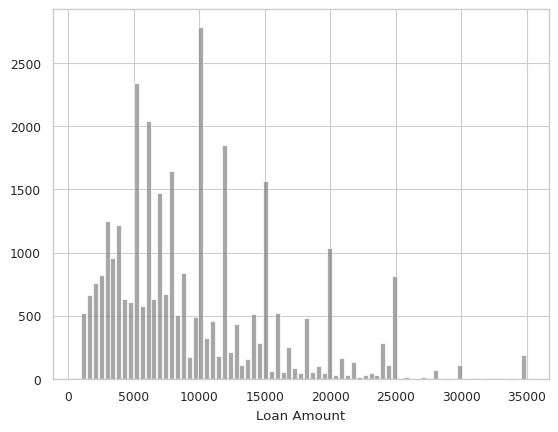

In [70]:
n, bins, patches = plt.hist(x=data['loan_amnt'], bins='auto', color='grey',alpha=0.7, rwidth=0.85)
plt.xlabel("Loan Amount")
plt.show()

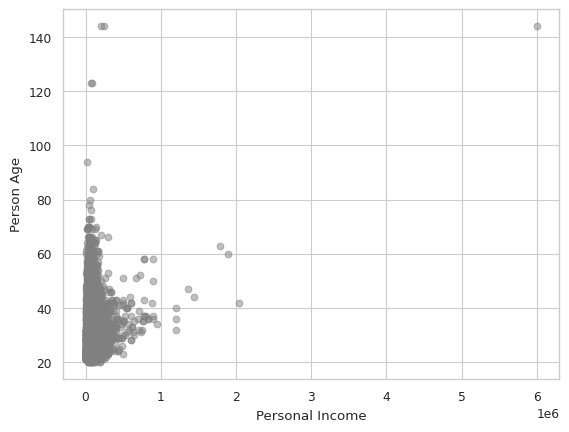

In [71]:
# Plot a scatter plot of income against age
plt.scatter(data['person_income'], data['person_age'],c='grey', alpha=0.5)
plt.xlabel('Personal Income')
plt.ylabel('Person Age')
plt.show()

In [72]:
# Create a cross table of the loan intent and loan status
pd.crosstab(data["loan_intent"], data["loan_status"], margins = True)

loan_status,0,1,All
loan_intent,,,
DEBTCONSOLIDATION,3722,1490,5212
EDUCATION,5342,1111,6453
HOMEIMPROVEMENT,2664,941,3605
MEDICAL,4450,1621,6071
PERSONAL,4423,1098,5521
VENTURE,4872,847,5719
All,25473,7108,32581


In [73]:
# Create a cross table of home ownership, loan status, and grade
pd.crosstab(data["person_home_ownership"],[data["loan_status"],data["loan_grade"]])

loan_status               0                                 1             \
loan_grade                A     B     C    D    E   F  G    A     B    C   
person_home_ownership                                                      
MORTGAGE               5219  3729  1934  658  178  36  0  239   324  321   
OTHER                    23    29    11    9    2   0  0    3     5    6   
OWN                     860   770   464  264   26   7  0   66    34   31   
RENT                   3602  4222  2710  554  137  28  1  765  1338  981   

loan_status                               
loan_grade                D    E   F   G  
person_home_ownership                     
MORTGAGE                553  161  61  31  
OTHER                    11    6   2   0  
OWN                      18   31   8   5  
RENT                   1559  423  99  27

In [74]:
# Create a cross table of home ownership, loan status, and average percent income
pd.crosstab(data["person_home_ownership"], data["loan_status"], values=data["loan_percent_income"], aggfunc="mean")

loan_status,0,1
person_home_ownership,,
MORTGAGE,0.14650,0.18488
OTHER,0.14378,0.30000
OWN,0.18001,0.29736
RENT,0.14461,0.26486


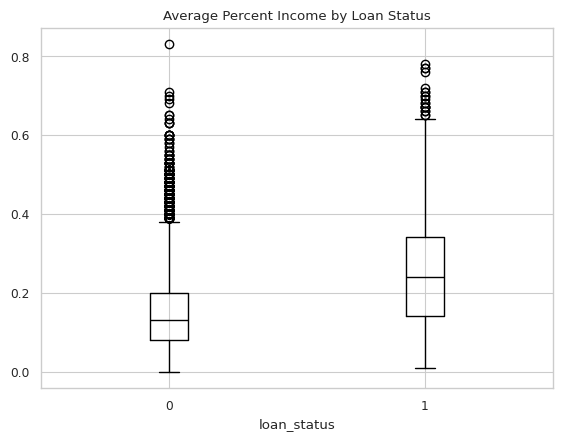

In [75]:
 # Create a box plot of percentage income by loan status
 # 0 - positive skew, whiskers from minimum to maximum, with outliers, median = 0.13
 # 1 - normal skew, , whiskers from minimum to maximum, with outliers, median = 0.24
data.boxplot(column = ['loan_percent_income'], by = 'loan_status', color="black")
plt.title('Average Percent Income by Loan Status')
plt.suptitle('')
plt.show()

In [76]:
grouped=data.groupby(['loan_status'])['loan_percent_income'].median().reset_index()
grouped

,loan_status,loan_percent_income
0,0,0.13000
1,1,0.24000


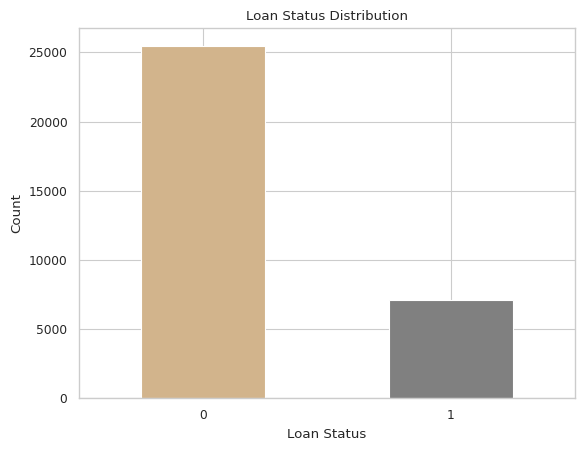

,count
loan_status,
0,25473
1,7108


In [77]:
data["loan_status"].value_counts().plot(kind='bar', color=['tan', 'grey'])
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
data["loan_status"].value_counts()

In [ ]:
# 2. Data preprocessing

In [ ]:
# 2.1. Replace outliers

In [78]:
# Create the cross table for loan status, home ownership, and the max employment length
pd.crosstab(data["loan_status"],data["person_home_ownership"], values=data["person_emp_length"], aggfunc="max")

person_home_ownership,MORTGAGE,OTHER,OWN,RENT
loan_status,,,,
0,123.00000,24.00000,31.00000,41.00000
1,34.00000,11.00000,17.00000,123.00000


In [79]:
# Create an array of indices where employment length is greater than 60
indices = data[data["person_emp_length"] > 60].index

In [80]:
# Drop the records from the data based on the indices and create a new dataframe
data = data.drop(indices)

In [81]:
# Create the cross table from earlier and include minimum employment length
pd.crosstab(data["loan_status"],data["person_home_ownership"], values=data['person_emp_length'], aggfunc=['min','max'])

min                              max           \
person_home_ownership MORTGAGE   OTHER     OWN    RENT MORTGAGE    OTHER   
loan_status                                                                
0                      0.00000 0.00000 0.00000 0.00000 38.00000 24.00000   
1                      0.00000 0.00000 0.00000 0.00000 34.00000 11.00000   

                                         
person_home_ownership      OWN     RENT  
loan_status                              
0                     31.00000 41.00000  
1                     17.00000 27.00000

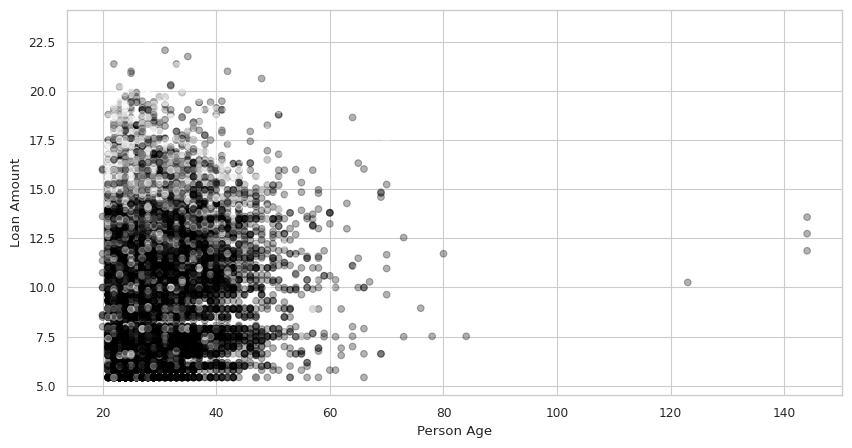

In [82]:
# Create the scatter plot for age and amount
plt.figure(figsize=(10, 5))
plt.scatter(data["person_age"], data["loan_int_rate"], c = data['loan_status'], alpha=0.3, cmap='gray')
plt.xlabel("Person Age")
plt.ylabel("Loan Amount")
plt.show()

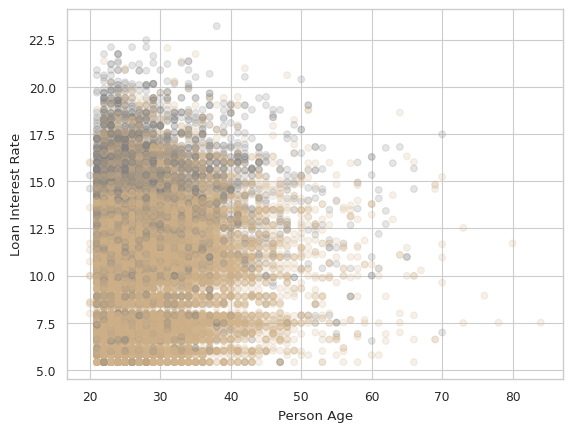

In [83]:
# Use Pandas to drop the record from the data frame and create a new one
import matplotlib.colors as mcolors  # Importa a biblioteca de cores
data = data.drop(data[data["person_age"] > 100].index)

# Create a scatter plot of age and interest rate
colors = ["tan","grey"]
plt.scatter(data["person_age"], data["loan_int_rate"], c = data['loan_status'],  cmap = mcolors.ListedColormap(colors), alpha=0.2)
plt.xlabel("Person Age")
plt.ylabel("Loan Interest Rate")
plt.show()

In [ ]:
# 2.2. Replace missing values

In [84]:
#Exploring Missing Values
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3115
loan_status,0
loan_percent_income,0


In [85]:
# Print the top five rows with nulls for employment length
data[data['person_emp_length'].isnull()].head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000,5.42000,1,0.16000,N,4
222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000,12.42000,0,0.19000,N,2
379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,NaN,1,0.23000,N,3
407,25,52000,RENT,NaN,PERSONAL,B,24000,10.74000,1,0.46000,N,2
408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250,15.27000,0,0.13000,Y,3


In [86]:
# Replace the null values with the median value for all employment lengths
data['person_emp_length'] = data['person_emp_length'].fillna(data['person_emp_length'].median())

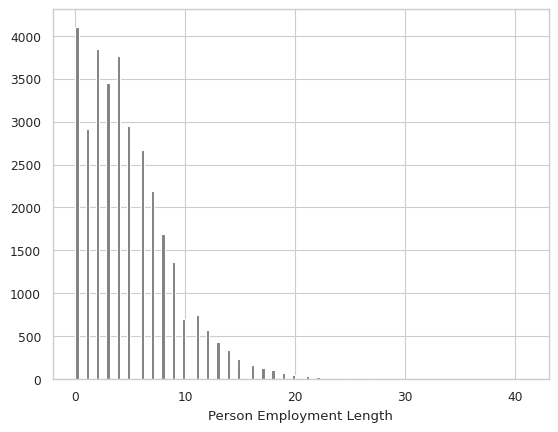

In [87]:
# Create a histogram of employment length
n, bins, patches = plt.hist(data['person_emp_length'], bins='auto', color='grey')
plt.xlabel("Person Employment Length")
plt.show()

In [88]:
# Store the array on indices
indices = data[data['loan_int_rate'].isnull()].index

# Save the new data without missing data
data = data.drop(indices)

In [89]:
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [90]:
# Create two data sets for numeric and non-numeric data
data_num = data.select_dtypes(exclude=['object'])
data_str = data.select_dtypes(include=['object'])

# One-hot encode the non-numeric columns
data_str_onehot = pd.get_dummies(data_str)

# Union the one-hot encoded columns to the numeric ones
data = pd.concat([data_num, data_str_onehot], axis=1)

# Print the columns in the new data set
data.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
1,21,9600,5.00000,1000,11.14000,0,0.10000,2,False,False,...,False,False,True,False,False,False,False,False,True,False
2,25,9600,1.00000,5500,12.87000,1,0.57000,3,True,False,...,False,False,False,True,False,False,False,False,True,False
3,23,65500,4.00000,35000,15.23000,1,0.53000,2,False,False,...,False,False,False,True,False,False,False,False,True,False
4,24,54400,8.00000,35000,14.27000,1,0.55000,4,False,False,...,False,False,False,True,False,False,False,False,False,True
5,21,9900,2.00000,2500,7.14000,1,0.25000,2,False,False,...,True,True,False,False,False,False,False,False,True,False


In [ ]:
# Heatmap with Correlation

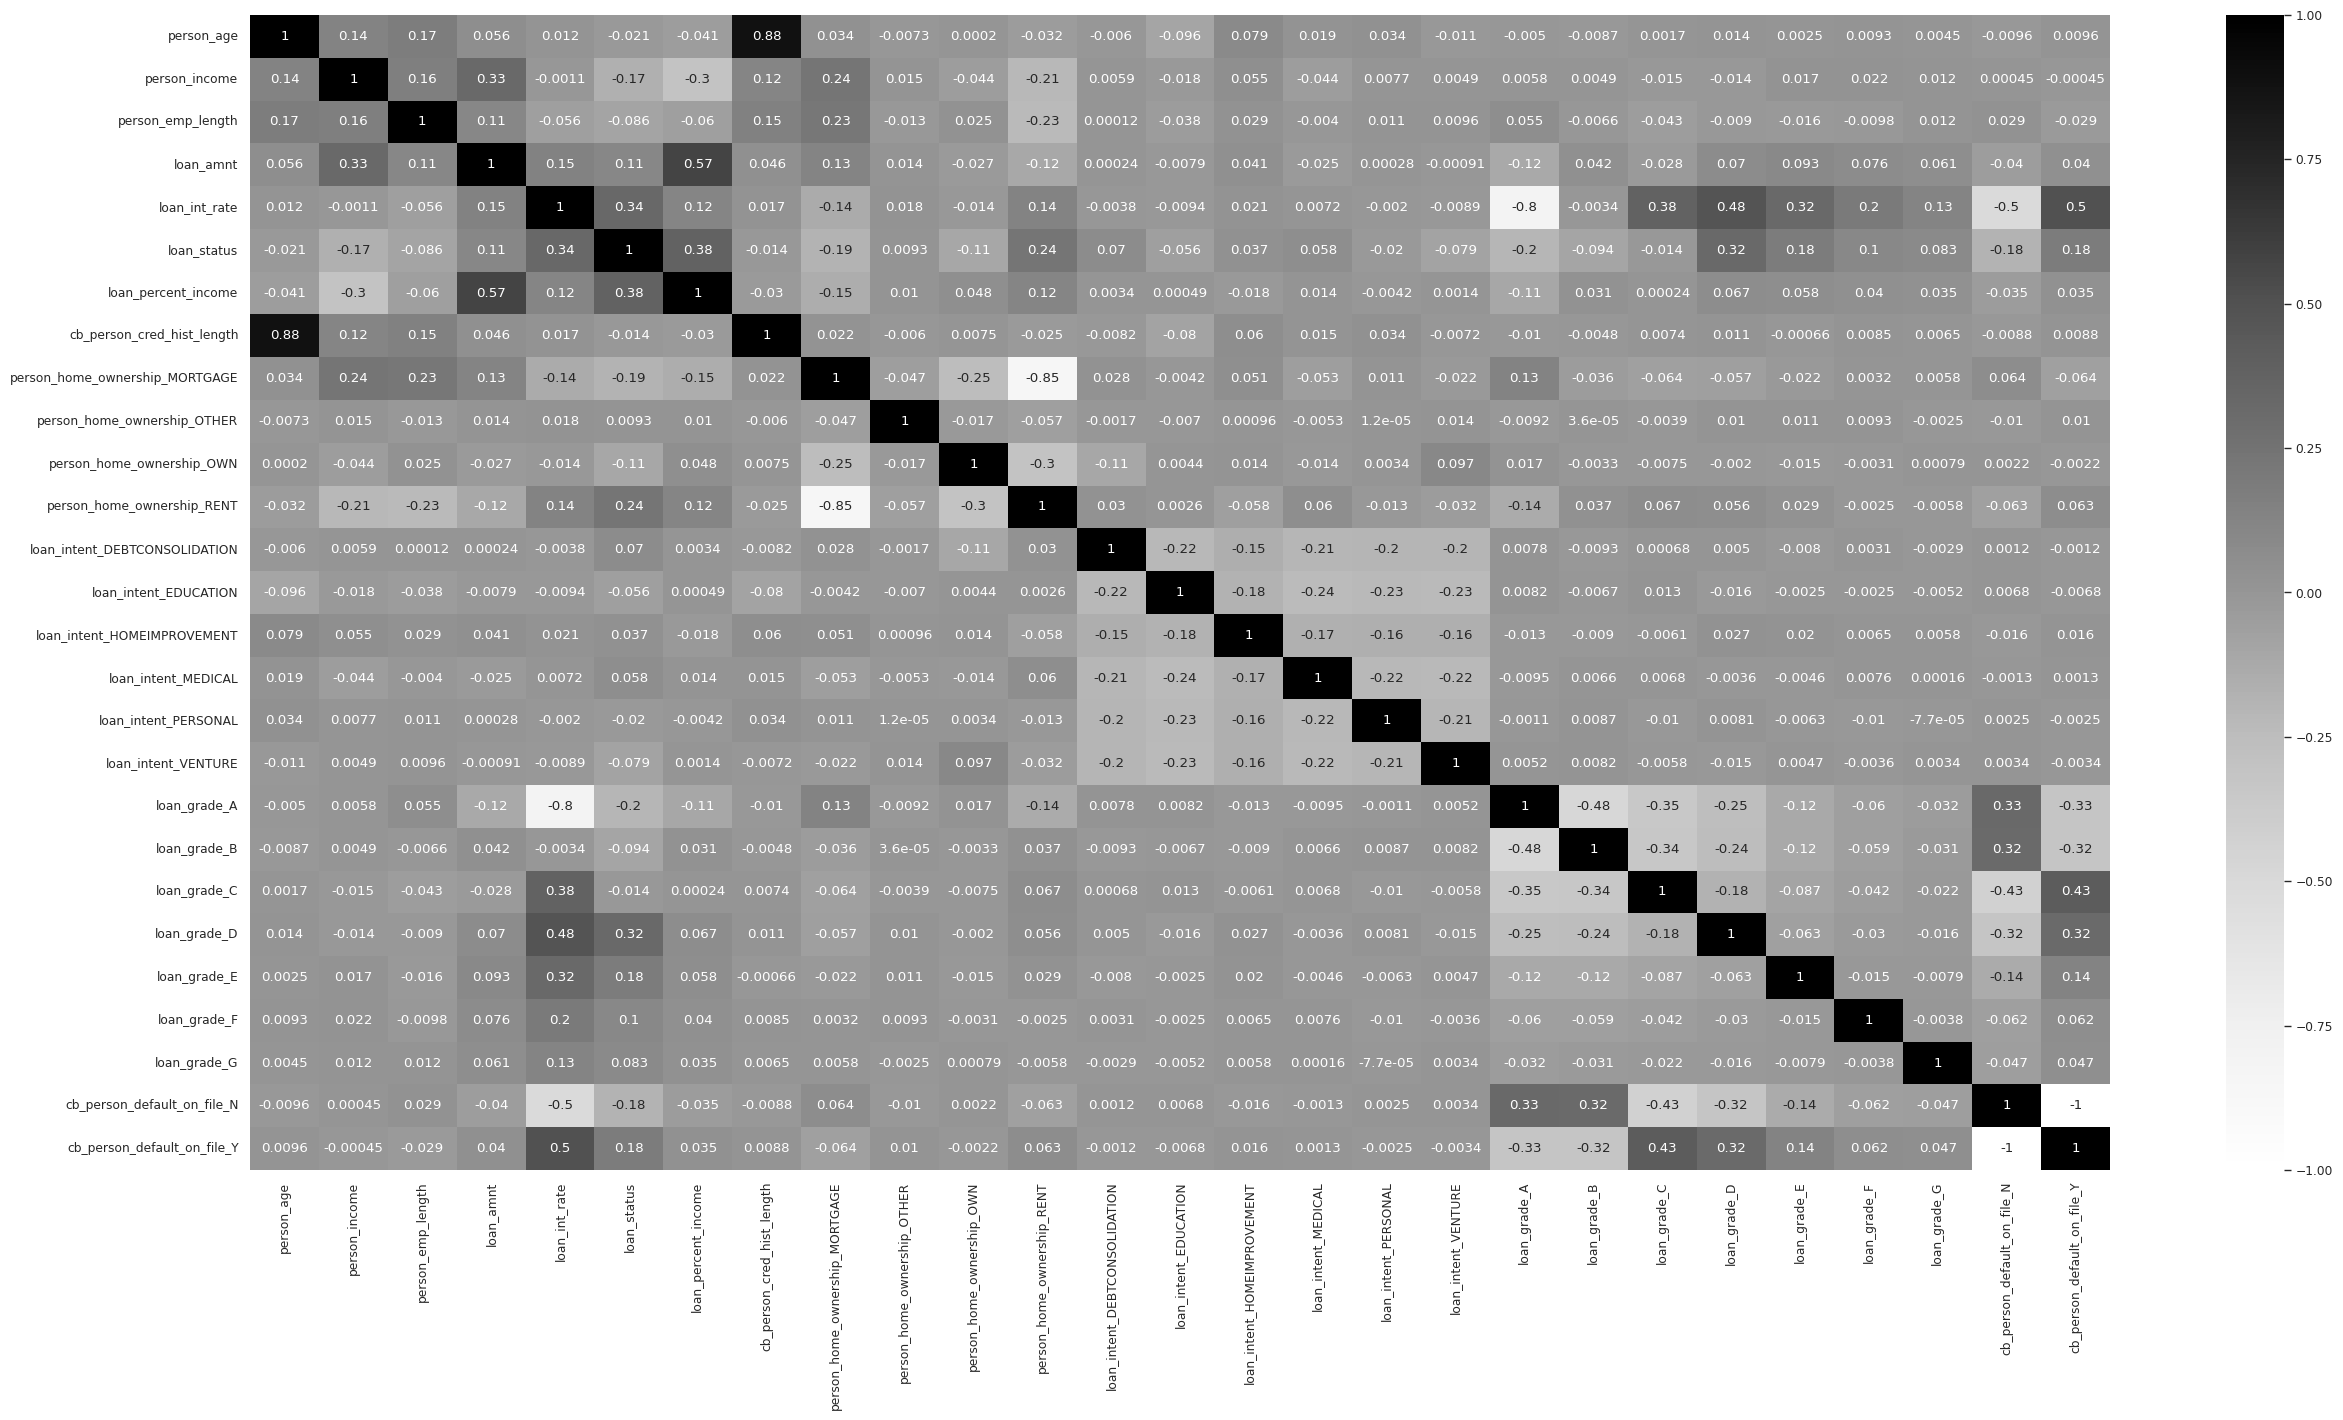

In [91]:
plt.figure(figsize=(30, 15))
sns.heatmap(data.corr(), annot=True, cmap='Greys')
plt.show()

In [ ]:
# 3. Model

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, auc, roc_curve
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import KFold
import xgboost as xgb
import pickle

In [98]:
# Create the X and y data sets
X = data.drop('loan_status', axis=1)
y = data[['loan_status']]

# Use test_train_split to create the training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=123)

In [99]:
X_test

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
31622,49,45000,2.00000,15000,13.49000,0.33000,12,False,False,False,...,False,False,False,True,False,False,False,False,True,False
24935,34,60500,3.00000,11200,15.62000,0.19000,10,False,False,False,...,False,False,False,False,True,False,False,False,False,True
15342,21,62004,0.00000,15000,7.29000,0.24000,4,False,False,False,...,True,True,False,False,False,False,False,False,True,False
3460,25,68000,9.00000,10800,10.74000,0.16000,2,False,False,False,...,True,False,True,False,False,False,False,False,True,False
16424,23,58800,7.00000,3000,10.36000,0.05000,3,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25231,29,81900,13.00000,8000,7.66000,0.10000,10,True,False,False,...,True,True,False,False,False,False,False,False,True,False
30380,37,89532,9.00000,6600,12.53000,0.07000,12,False,False,False,...,False,False,True,False,False,False,False,False,True,False
29849,37,40000,2.00000,16000,10.99000,0.40000,15,True,False,False,...,False,False,True,False,False,False,False,False,True,False
1780,23,29004,2.00000,6000,11.99000,0.21000,2,True,False,False,...,False,False,True,False,False,False,False,False,True,False


In [100]:
# Scaler for training and test data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_slr = scaler.fit_transform(X_train) # Creating a X_train variable scaled, in order to don't lose the original X_train for future calculations
X_test_slr = scaler.transform(X_test)

with open("credit_risk_model.pkl", "wb") as f:
    pickle.dump(scaler,f)

In [101]:
log_clf = LogisticRegression(solver='lbfgs', max_iter=1000)
rnd_clf = RandomForestClassifier()
svm_clf = SVC()
knn_clf = KNeighborsClassifier()
grd_clf = GradientBoostingClassifier()
xgb_clf = xgb.XGBClassifier()

voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('rf', rnd_clf),
        ('xgb', xgb_clf)
    ],
    voting='soft'
)

In [ ]:
# Training and validation

In [102]:
# Predict and evaluate all different models: the best is Random Forest or XGBClassifier

for clf in (log_clf, rnd_clf, svm_clf, knn_clf, grd_clf, xgb_clf, voting_clf):
    clf.fit(X_train_slr, np.ravel(y_train))
    y_pred = clf.predict(X_test_slr)
    print(f"The {clf.__class__.__name__} has an Accuracy: {accuracy_score(y_test, y_pred):.4f} , and a Precision of: {precision_score(y_test, y_pred):.4f} ")

The LogisticRegression has an Accuracy: 0.8674 , and a Precision of: 0.7638 
The RandomForestClassifier has an Accuracy: 0.9291 , and a Precision of: 0.9600 
The SVC has an Accuracy: 0.9079 , and a Precision of: 0.9149 
The KNeighborsClassifier has an Accuracy: 0.8907 , and a Precision of: 0.8489 
The GradientBoostingClassifier has an Accuracy: 0.9218 , and a Precision of: 0.9267 
The XGBClassifier has an Accuracy: 0.9308 , and a Precision of: 0.9377 
The VotingClassifier has an Accuracy: 0.9290 , and a Precision of: 0.9459 


Validation of the LogisticRegression model: 
loan_status
0    9845
1    1939
Name: count, dtype: int64
The Report from LogisticRegression:
              precision    recall  f1-score   support

 Non-Default       0.89      0.95      0.92      9198
     Default       0.76      0.57      0.65      2586

    accuracy                           0.87     11784
   macro avg       0.83      0.76      0.79     11784
weighted avg       0.86      0.87      0.86     11784

The LogisticRegression has an Accuracy: 0.8674, and a Precision of: 0.7638


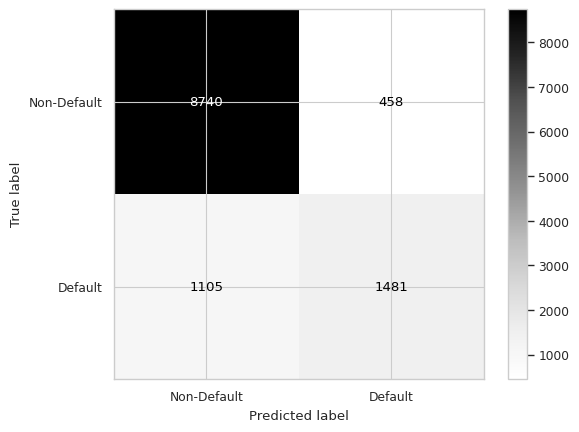

Validation of the RandomForestClassifier model: 
loan_status
0    9872
1    1912
Name: count, dtype: int64
The Report from RandomForestClassifier:
              precision    recall  f1-score   support

 Non-Default       0.92      0.99      0.96      9198
     Default       0.96      0.71      0.82      2586

    accuracy                           0.93     11784
   macro avg       0.94      0.85      0.89     11784
weighted avg       0.93      0.93      0.93     11784

The RandomForestClassifier has an Accuracy: 0.9301, and a Precision of: 0.9608


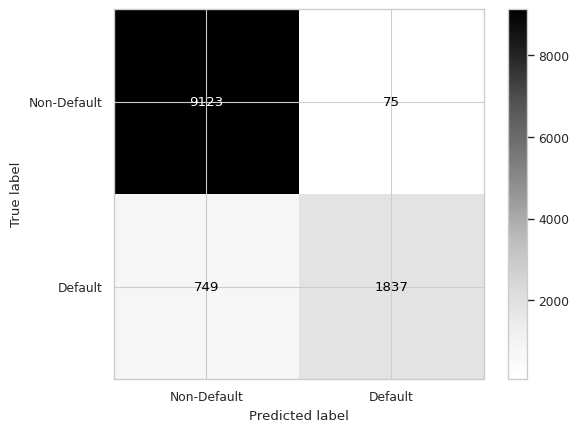

Validation of the XGBClassifier model: 
loan_status
0    9762
1    2022
Name: count, dtype: int64
The Report from XGBClassifier:
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      9198
     Default       0.94      0.73      0.82      2586

    accuracy                           0.93     11784
   macro avg       0.93      0.86      0.89     11784
weighted avg       0.93      0.93      0.93     11784

The XGBClassifier has an Accuracy: 0.9308, and a Precision of: 0.9377


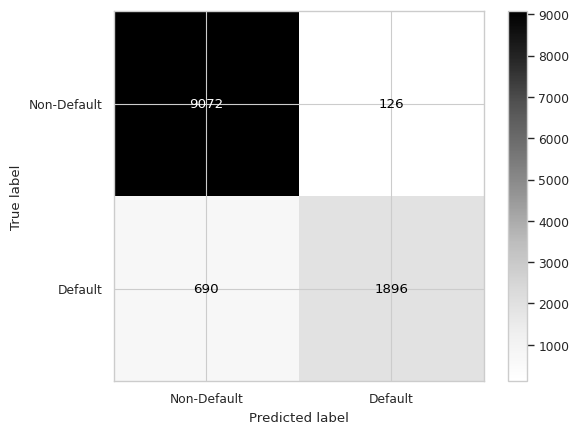

Validation of the VotingClassifier model: 
loan_status
0    9825
1    1959
Name: count, dtype: int64
The Report from VotingClassifier:
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      9198
     Default       0.95      0.72      0.82      2586

    accuracy                           0.93     11784
   macro avg       0.94      0.85      0.89     11784
weighted avg       0.93      0.93      0.93     11784

The VotingClassifier has an Accuracy: 0.9291, and a Precision of: 0.9469


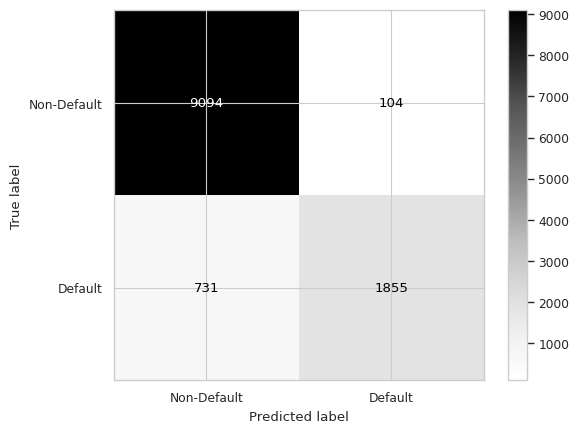

In [103]:
# True Positive (TP): Correctly predicted positive cases.
# True Negative (TN): Correctly predicted negative cases.
# False Positive (FP): Predicted positive when it is actually negative (Type I error).
# False Negative (FN): Predicted negative when it is actually positive (Type II error).


# Import necessary libraries (assuming they were imported earlier in your script)
colors = ['grey', 'tan', 'black', 'silver', 'yellow', 'brown']  # Define a list of colors for potential plotting purposes

# Initialize lists to store evaluation metrics for different models
model_name_list = []       # List to store model names for each classifier
fallout_list = []          # List to store False Positive Rate (FPR) for ROC curves
sensitivity_list = []      # List to store True Positive Rate (TPR) for ROC curves
thresholds_list = []       # List to store threshold values from ROC calculation
roc_auc_list = []          # List to store AUC values for each model
preds_df_all = pd.DataFrame()  # DataFrame to consolidate probabilities and predictions for all models

# Loop through the classifiers to fit, predict, and evaluate them
for idx, clf in enumerate((log_clf, rnd_clf, xgb_clf, voting_clf)):  # Iterate through classifiers

    # Store and print the model name
    model_name_list.append(clf.__class__.__name__)  # Append the class name of the current classifier to the model list
    print(f"Validation of the {model_name_list[idx]} model: ")  # Display the current model being validated

    # Fit the current classifier on the training data
    clf.fit(X_train_slr, np.ravel(y_train))  # Train the model with X_train_slr (features) and y_train (target)

    # Predict probabilities for the test data
    preds = clf.predict_proba(X_test_slr)  # Predict class probabilities; `predict_proba` returns probabilities for each class

    # Create a DataFrame to store the probabilities of the positive class (e.g., default)
    preds_df = pd.DataFrame(preds[:, 1], columns=['prob_default'])  # Extract probabilities for the positive class

    # Store the probabilities in a consolidated DataFrame
    preds_df_all[f"prob_default {model_name_list[idx]}"] = preds_df['prob_default']  # Add current model's probabilities to `preds_df_all`


    threshold = 0.5  # Default threshold of 0.5 to classify positive vs negative
    preds_df["loan_status"] = preds_df["prob_default"].apply(lambda x: 1 if x > threshold else 0)  # Binary classification
    preds_df_all[f"loan_status {model_name_list[idx]}"] = preds_df['loan_status']
    print(preds_df["loan_status"].value_counts())  # Display class distribution for predicted values

    # --- Classification Report ---

    # Generate and print the classification report
    print(f"The Report from {model_name_list[idx]}:")
    target_names = ['Non-Default', 'Default']  # Define class names for the report
    print(classification_report(y_test, preds_df["loan_status"], target_names=target_names))  # Evaluation metrics

    # Print accuracy and precision metrics
    print(f"The {model_name_list[idx]} has an Accuracy: {accuracy_score(y_test, preds_df['loan_status']):.4f}, "
          f"and a Precision of: {precision_score(y_test, preds_df['loan_status']):.4f}")

    # --- Confusion Matrix ---

    # Compute the confusion matrix
    cm = confusion_matrix(y_test, preds_df['loan_status'])  # Confusion matrix: actual vs predicted values

    class_names = ['Non-Default', 'Default']

    # Plot and display the confusion matrix
    display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)  # Configure the display
    #display_cm.plot()  # Plot the confusion matrix
    display_cm.plot(cmap = 'Greys')
    plt.show()  # Show the plot

    # --- ROC Curve and AUC ---

    # Evaluate the model using ROC-AUC
    prob_default = preds[:, 1]  # Extract probabilities of the positive class

    # Calculate ROC curve metrics: FPR (fallout), TPR (sensitivity), and thresholds
    fallout, sensitivity, thresholds = roc_curve(y_test, prob_default)  # Compute ROC metrics

    # Calculate the Area Under the Curve (AUC) for ROC
    roc_auc = roc_auc_score(y_test, prob_default)  # AUC score for the current model

    # Append the ROC metrics to the respective lists
    fallout_list.append(fallout)  # Store FPR values
    sensitivity_list.append(sensitivity)  # Store TPR values
    thresholds_list.append(thresholds)  # Store thresholds
    roc_auc_list.append(roc_auc)  # Store AUC score


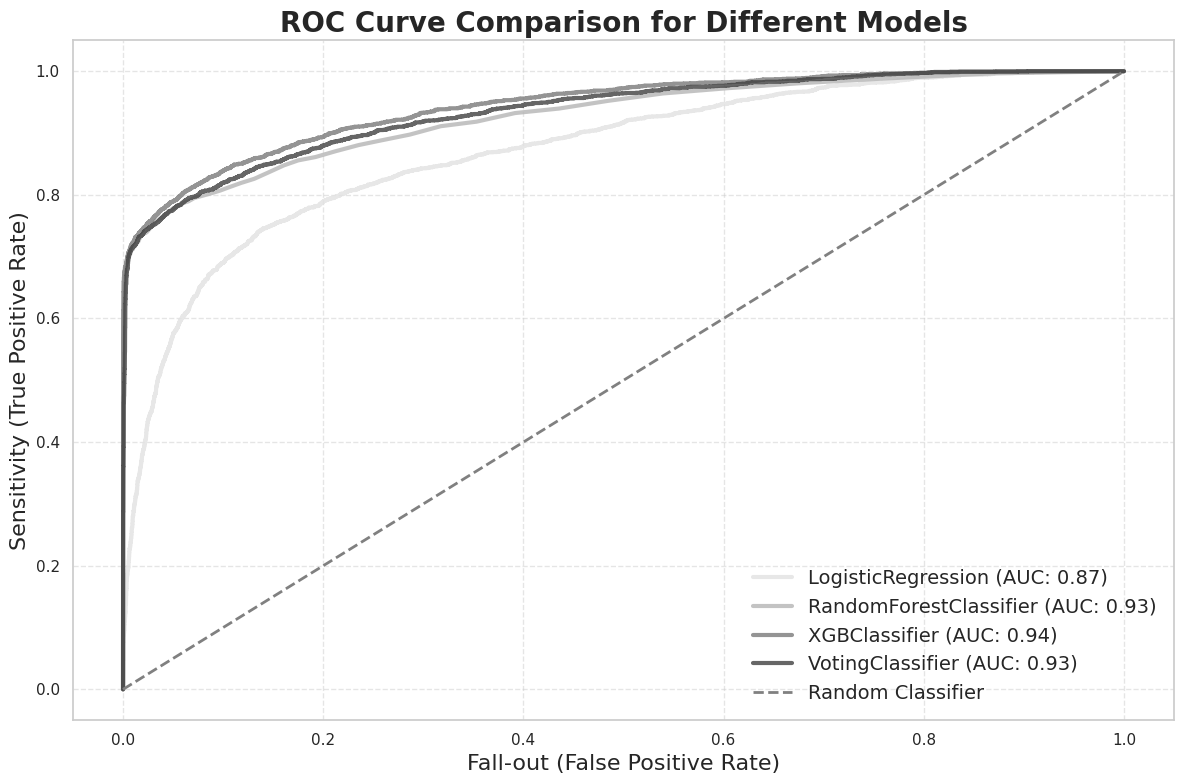

In [104]:
# Plot the ROC Curve for all models with improvements:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
colors = sns.color_palette("Greys", len(model_name_list))
plt.figure(figsize=(12, 8))

for idx in range(len(model_name_list)):
    plt.plot(fallout_list[idx], sensitivity_list[idx],
             color=colors[idx], linewidth=3, alpha=0.8, label=f"{model_name_list[idx]} (AUC: {roc_auc_list[idx]:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier', linewidth=2)
plt.title("ROC Curve Comparison for Different Models", fontsize=20, fontweight='bold', family='DejaVu Sans')
plt.xlabel('Fall-out (False Positive Rate)', fontsize=16, family='DejaVu Sans')
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=16, family='DejaVu Sans')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=14, frameon=False, fancybox=True)
plt.tight_layout()
plt.show()


In [105]:
y_test

,loan_status
31622,1
24935,1
15342,0
3460,0
16424,1
...,...
25231,0
30380,0
29849,0
1780,0


In [106]:
# Concat all True Status Loan and All Prob and Show
# Using test instances

true_df = pd.DataFrame()

true_df["true_loan_status"] = y_test
true_and_pred_df = pd.concat([true_df.reset_index(drop = True), preds_df_all], axis = 1)
true_and_pred_df

,true_loan_status,prob_default LogisticRegression,loan_status LogisticRegression,prob_default RandomForestClassifier,loan_status RandomForestClassifier,prob_default XGBClassifier,loan_status XGBClassifier,prob_default VotingClassifier,loan_status VotingClassifier
0,1,0.64696,1,0.97000,1,0.99531,1,0.87076,1
1,1,0.82953,1,0.95000,1,0.97448,1,0.92800,1
2,0,0.08574,0,0.03000,0,0.00039,0,0.03204,0
3,0,0.05766,0,0.01000,0,0.00121,0,0.02296,0
4,1,0.04484,0,0.06000,0,0.09189,0,0.07224,0
...,...,...,...,...,...,...,...,...,...
11779,0,0.01081,0,0.00000,0,0.00063,0,0.00381,0
11780,0,0.08266,0,0.04000,0,0.01250,0,0.04172,0
11781,0,0.54113,1,0.14000,0,0.03948,0,0.23687,0
11782,0,0.22643,0,0.10000,0,0.31573,0,0.20739,0


In [107]:
true_and_pred_df = true_and_pred_df[["true_loan_status", "prob_default XGBClassifier", "loan_status XGBClassifier"]]

true_and_pred_df = true_and_pred_df.rename(columns={
    "prob_default XGBClassifier": "prob_default",
    "loan_status XGBClassifier": "pred_loan_status"
})

true_and_pred_df

,true_loan_status,prob_default,pred_loan_status
0,1,0.99531,1
1,1,0.97448,1
2,0,0.00039,0
3,0,0.00121,0
4,1,0.09189,0
...,...,...,...
11779,0,0.00063,0
11780,0,0.01250,0
11781,0,0.03948,0
11782,0,0.31573,0


In [108]:
pd.DataFrame(X_test)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
31622,49,45000,2.00000,15000,13.49000,0.33000,12,False,False,False,...,False,False,False,True,False,False,False,False,True,False
24935,34,60500,3.00000,11200,15.62000,0.19000,10,False,False,False,...,False,False,False,False,True,False,False,False,False,True
15342,21,62004,0.00000,15000,7.29000,0.24000,4,False,False,False,...,True,True,False,False,False,False,False,False,True,False
3460,25,68000,9.00000,10800,10.74000,0.16000,2,False,False,False,...,True,False,True,False,False,False,False,False,True,False
16424,23,58800,7.00000,3000,10.36000,0.05000,3,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25231,29,81900,13.00000,8000,7.66000,0.10000,10,True,False,False,...,True,True,False,False,False,False,False,False,True,False
30380,37,89532,9.00000,6600,12.53000,0.07000,12,False,False,False,...,False,False,True,False,False,False,False,False,True,False
29849,37,40000,2.00000,16000,10.99000,0.40000,15,True,False,False,...,False,False,True,False,False,False,False,False,True,False
1780,23,29004,2.00000,6000,11.99000,0.21000,2,True,False,False,...,False,False,True,False,False,False,False,False,True,False


In [109]:
# Print the first two numbers from the report
print(precision_recall_fscore_support(y_test,preds_df['loan_status'])[0])

[0.92559796 0.94691169]


In [110]:
# Measure Impact with XGB Classifier
# XGB Classifier is the best, we work further only with this classifier

In [111]:
# 4. Acceptance Rate and trashold


# use an Acceptance Rateto help us to define the trashhold.
# The threshold is the decision boundary that determines whether a prediction is classified as positive
# (e.g., loan accepted) or negative (e.g., loan rejected).
# By default, many models use a threshold of 0.5 (50%), meaning a prediction with a probability above 0.5 is classified as positive.

<Axes: >

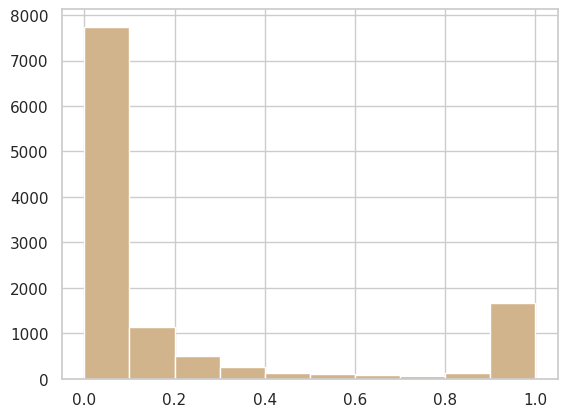

In [112]:
true_and_pred_df["prob_default"].hist(color = "tan")

In [113]:
# Using the Acceptance Rate to calculate the Threshold:

# Check the statistics of the probabilities of default
pd.options.display.float_format = '{:.5f}'.format
print(true_and_pred_df["prob_default"].describe())

count   11784.00000
mean        0.21400
std         0.34293
min         0.00000
25%         0.00904
50%         0.04273
75%         0.19429
max         0.99999
Name: prob_default, dtype: float64


In [114]:
# Calculate the threshold for a 85% acceptance rate
# 15% of loans above treshold is accually propense to became deliquent
threshold_85 = np.quantile(true_and_pred_df["prob_default"], 0.85)
print(threshold_85)

# Apply acceptance rate threshold
true_and_pred_df["pred_loan_status"] = true_and_pred_df["prob_default"].apply(lambda x: 1 if x > threshold_85 else 0)

# Print the counts of loan status after the threshold
print(true_and_pred_df["pred_loan_status"].value_counts())

0.82746583
pred_loan_status
0    10016
1     1768
Name: count, dtype: int64


In [46]:
# Bad rate
# Bad Rate - the higher is our acceptance rate the higher is our Bad Rate.

In [115]:
# Create a subset of only accepted loans
accepted_loans = true_and_pred_df[true_and_pred_df["pred_loan_status"] == 0]

# Calculate the bad rate
print(np.sum(accepted_loans['true_loan_status']) / accepted_loans['true_loan_status'].count())

0.0832667731629393


In [116]:
# Print the statistics of the loan amount column
print(X_test['loan_amnt'].describe())
avg_loan = np.mean(X_test['loan_amnt'])
pd.options.display.float_format = '${:,.2f}'.format
print(pd.crosstab(true_and_pred_df['true_loan_status'], true_and_pred_df['pred_loan_status']).apply(lambda x: x * avg_loan, axis = 0))

count   11784.00000
mean     9556.28394
std      6238.00567
min       500.00000
25%      5000.00000
50%      8000.00000
75%     12000.00000
max     35000.00000
Name: loan_amnt, dtype: float64
pred_loan_status              0              1
true_loan_status                              
0                $87,745,799.18    $152,900.54
1                 $7,969,940.81 $16,742,609.47


In [117]:
# Set all the acceptance rates to test
accept_rates = [1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]

In [118]:
# Estimated Value: The estimated value represents the total expected value of the accepted loans,
# taking into account both the loans that will be repaid and the loans that will result in losses due to default.

test_pred = pd.DataFrame()
test_pred["prob_default"] = true_and_pred_df["prob_default"]

# Create lists to store thresholds and bad rates
thresholds = []
bad_rates = []
num_accepted_loans = []
avg_loan_amnt = []
estimated_value = []

# Populate the arrays for the strategy table with a for loop
for idx, rate in enumerate(accept_rates):

    # Calculate the threshold for the acceptance rate
    thresh = np.quantile(test_pred["prob_default"], rate).round(3)

    # Add the threshold value to the list of thresholds
    thresholds.append(np.quantile(test_pred['prob_default'], rate).round(3))

    # Reassign the loan_status value using the threshold
    true_and_pred_df['pred_loan_status'] = true_and_pred_df['prob_default'].apply(lambda x: 1 if x > thresh else 0)

    # Create a set of accepted loans using this acceptance rate
    accepted_loans = true_and_pred_df[true_and_pred_df["pred_loan_status"] == 0]

    # Calculate and append the bad rate using the acceptance rate
    bad_rate = np.sum((accepted_loans["true_loan_status"]) / len(accepted_loans["true_loan_status"])).round(3)
    bad_rates.append(bad_rate)

    num_accepted_loans.append(len(accepted_loans))

    avg_loan_amnt.append(np.mean(X_test["loan_amnt"]))

    #estimated_value.append( ((len(accepted_loans) * (1 - bad_rate)) * X_test["loan_amnt"]) - ( len(accepted_loans) * bad_rate * np.mean(X_test["loan_amnt"]) ) )

    estimated_val = ((len(accepted_loans) * (1 - bad_rate)) * np.mean(X_test["loan_amnt"])) - ( len(accepted_loans) * bad_rate * np.mean(X_test["loan_amnt"]) )

    estimated_value.append(estimated_val)

pd.options.display.float_format = '{:.5f}'.format

# Create a data frame of the strategy table
strat_df = pd.DataFrame(zip(accept_rates, thresholds, bad_rates, num_accepted_loans, avg_loan_amnt, estimated_value), columns = ['Acceptance Rate','Threshold','Bad Rate', 'Num Accepted Loans', 'Avg Loan Amnt', 'Estimated Value'])
strat_df

,Acceptance Rate,Threshold,Bad Rate,Num Accepted Loans,Avg Loan Amnt,Estimated Value
0,1.00000,1.00000,0.21900,11784,9556.28394,63287522.50000
1,0.95000,0.99600,0.17800,11186,9556.28394,68841405.37763
2,0.90000,0.98500,0.13300,10615,9556.28394,74456926.28670
3,0.85000,0.82700,0.08300,10015,9556.28394,79818957.20787
4,0.80000,0.32000,0.06200,9429,9556.28394,78933032.34852
5,0.75000,0.19400,0.05000,8833,9556.28394,75969590.47225
6,0.70000,0.13200,0.04300,8259,9556.28394,72137769.07396
7,0.65000,0.09600,0.03600,7662,9556.28394,67948389.75560
8,0.60000,0.07200,0.03100,7068,9556.28394,63356098.39358
9,0.55000,0.05500,0.02500,6489,9556.28394,58910190.18903


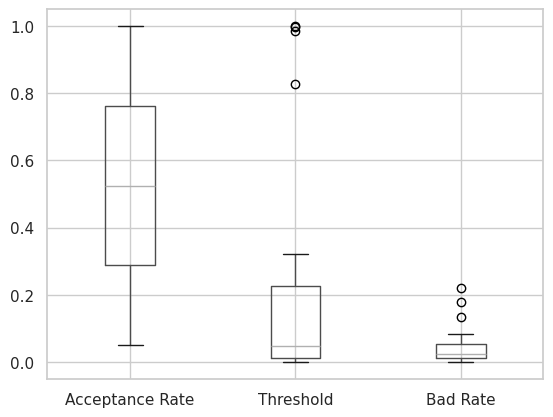

In [119]:
# Visualize the distributions in the strategy table with a boxplot
# Acceptance Rate - normal skew, median = 0.52
# Threshold - positive skew, median = 0.05
# Bad Rate - positive skew, median = 0.02
strat_df[["Acceptance Rate", "Threshold" , "Bad Rate"]].boxplot()
plt.show()

In [120]:
# strat_df["Acceptance Rate"].median()
# strat_df["Threshold"].median()
# strat_df["Bad Rate"].median()


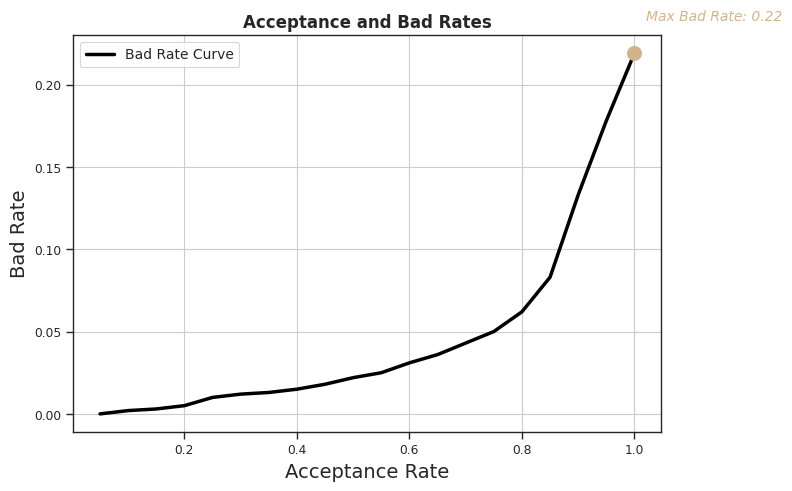

In [121]:
sns.set(style="ticks", context="paper")

# maximum Bad Rate
max_bad_rate_index = strat_df['Bad Rate'].idxmax()
max_bad_rate = strat_df['Bad Rate'][max_bad_rate_index]
max_acceptance_rate = strat_df['Acceptance Rate'][max_bad_rate_index]

# plot
plt.figure(figsize=(8, 5))
sns.lineplot(x=strat_df['Acceptance Rate'], y=strat_df['Bad Rate'], linewidth=2.5, label="Bad Rate Curve", color='black')
plt.scatter(max_acceptance_rate, max_bad_rate, color='tan', s=100, zorder=5)  # Red point for max bad rate
plt.text(max_acceptance_rate + 0.02, max_bad_rate + 0.02, f'Max Bad Rate: {max_bad_rate:.2f}',  color='tan', fontsize=10,  style='italic')
plt.xlabel('Acceptance Rate', fontsize=14)
plt.ylabel('Bad Rate', fontsize=14)
plt.title('Acceptance and Bad Rates', fontsize=12, weight='bold')
plt.grid(True)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()  # Adjust layout to avoid any overlap
plt.show()

In [122]:
# Print the row with the max estimated value
strat_df.loc[strat_df['Estimated Value'] == np.max(strat_df['Estimated Value'])]

,Acceptance Rate,Threshold,Bad Rate,Num Accepted Loans,Avg Loan Amnt,Estimated Value
3,0.85000,0.82700,0.08300,10015,9556.28394,79818957.20787


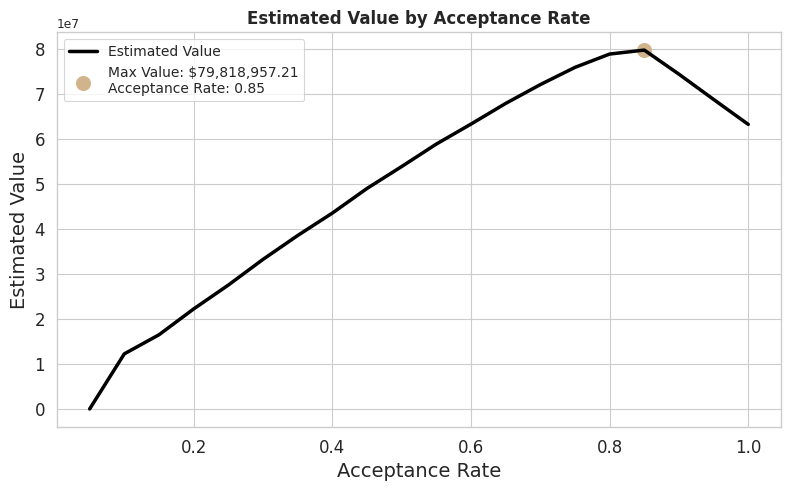

In [123]:
# the estimated value is impacted by the acceptance rate, bad rate, and also Average Loan Amount.
# In the chart bellow we can see how the estimated Value varies depending of the acceptance rate.

sns.set(style="whitegrid", context="paper")

# the maximum value in 'Estimated Value'
max_index = strat_df['Estimated Value'].idxmax()
max_value = strat_df['Estimated Value'][max_index]
max_acceptance_rate = strat_df['Acceptance Rate'][max_index]

# plot
plt.figure(figsize=(8, 5))
sns.lineplot(x=strat_df['Acceptance Rate'], y=strat_df['Estimated Value'], linewidth=2.5, label="Estimated Value", color='black')
max_value_formatted = f"${max_value:,.2f}"
plt.scatter(max_acceptance_rate, max_value, color='tan', s=100, label=f'Max Value: {max_value_formatted}\nAcceptance Rate: {max_acceptance_rate:.2f}')
plt.title('Estimated Value by Acceptance Rate', fontsize=12, weight='bold')
plt.xlabel('Acceptance Rate', fontsize=14)
plt.ylabel('Estimated Value', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 5. Total expected Loss ( total erwarteter Verlust (total EL))
# Calculate the bank's expected loss and assign it to a new column

In [124]:
true_and_pred_df

,true_loan_status,prob_default,pred_loan_status
0,1,0.99531,1
1,1,0.97448,1
2,0,0.00039,1
3,0,0.00121,1
4,1,0.09189,1
...,...,...,...
11779,0,0.00063,1
11780,0,0.01250,1
11781,0,0.03948,1
11782,0,0.31573,1


In [125]:
pd.DataFrame(X_test["loan_amnt"])

,loan_amnt
31622,15000
24935,11200
15342,15000
3460,10800
16424,3000
...,...
25231,8000
30380,6600
29849,16000
1780,6000


In [126]:
test_pred_df = pd.concat([true_and_pred_df, pd.DataFrame(X_test["loan_amnt"]).reset_index(drop = True)], axis = 1)
test_pred_df

,true_loan_status,prob_default,pred_loan_status,loan_amnt
0,1,0.99531,1,15000
1,1,0.97448,1,11200
2,0,0.00039,1,15000
3,0,0.00121,1,10800
4,1,0.09189,1,3000
...,...,...,...,...
11779,0,0.00063,1,8000
11780,0,0.01250,1,6600
11781,0,0.03948,1,16000
11782,0,0.31573,1,6000


In [127]:
# Probability of default (PD)
test_pred_df['prob_default']

# Exposure at default = loan amount (EAD)
test_pred_df['loan_amnt']

# Loss given default = 1.0 for total loss (LGD)
loss_given_default = 1

In [128]:
# EL - Ein höherer EL bedeutet ein höheres Kreditrisiko für die Bank. LS 1 und PD 1 ( Ausfallwahrscheinlichkeit 1) haben die höhste erwarteter Verlust (EL).
# Calculate the bank's expected loss and assign it to a new column
test_pred_df["expected_loss"] = test_pred_df["prob_default"] * test_pred_df["loan_amnt"] * loss_given_default
test_pred_df

,true_loan_status,prob_default,pred_loan_status,loan_amnt,expected_loss
0,1,0.99531,1,15000,14929.61615
1,1,0.97448,1,11200,10914.17437
2,0,0.00039,1,15000,5.87554
3,0,0.00121,1,10800,13.05430
4,1,0.09189,1,3000,275.65822
...,...,...,...,...,...
11779,0,0.00063,1,8000,5.04937
11780,0,0.01250,1,6600,82.47232
11781,0,0.03948,1,16000,631.72090
11782,0,0.31573,1,6000,1894.40668


In [129]:
# Calculate the total expected loss to two decimal places
tot_exp_loss = round(np.sum(test_pred_df['expected_loss']), 2)

# Print the total expected loss
print('Total expected loss: ', '${:,.2f}'.format(tot_exp_loss))

Total expected loss:  $26,854,405.39


In [130]:
# Select model and save it

In [62]:
model = xgb_clf

with open("credit_risk_model.pkl", "wb") as f:
    pickle.dump(model, f)

print(f"Die Datei ist erfolgreich gespeichert.")

Die Datei ist erfolgreich gespeichert.


In [ ]:
# https://medium.com/@danrlei.diegues_91903/credit-risk-modeling-in-python-e9b2379ebeb0
# https://github.com/DanrleiDiegues/credit-risk-classifier/blob/main/models/credit_risk_model.pkl